In [ ]:
import pandas as pd
data = pd.read_csv("binding.csv")


In [ ]:
import numpy as np
from cvxopt import matrix, solvers
from sklearn.base import BaseEstimator, ClassifierMixin

class SVM(BaseEstimator, ClassifierMixin):
    """
    Support Vector Machine (SVM) classifier implemented using
    quadratic programming.

    This class supports linear, polynomial, radial basis function (RBF),
    and custom precomputed kernels. It follows the scikit-learn estimator
    interface, allowing compatibility with standard ML workflows.

    Parameters
    ----------
    C : float, default=10
        Regularization parameter that controls the trade-off between
        maximizing the margin and minimizing classification error.

    kernel : str, default='poly'
        Kernel type to be used in the algorithm. Options are:
        'linear', 'poly', 'rbf', or 'Given'.

    r : float, default=1
        Independent term in the polynomial kernel.

    d : int, default=3
        Degree of the polynomial kernel.

    gamma : float, default=0.1
        Kernel coefficient for the RBF kernel.

    k_given : array-like, optional
        Precomputed kernel matrix used when kernel='Given'.

    Attributes
    ----------
    alpha : ndarray
        Lagrange multipliers obtained from the quadratic optimization.

    support_vectors : ndarray
        Subset of training data corresponding to non-zero alpha values.

    w : ndarray or None
        Weight vector (only for linear kernel).

    b : float
        Bias term of the decision function.

    Notes
    -----
    This implementation solves the dual optimization problem using
    quadratic programming via cvxopt.
    """
    def __init__(self, C=10, kernel='poly', r=1, d=3, gamma=0.1, k_given=None, eps=1e-10):

        self.C = C
        self.kernel = kernel
        self.r = r
        self.d = d
        self.gamma = gamma
        self.k_given = k_given
        self.eps = eps
       
        self.K_train = None
        self.X_train = None
        self.sample = None
        self.sv_indices = None
        self.alpha_sv = None
        self.y_sv = None
        self.support_vectors = None
        self.b = 0.0

    def _call_k_given(self, x1, x2, sample_override=None):

        if not callable(self.k_given):
            raise ValueError("k_given is not callable")
        sample_to_use = sample_override if sample_override is not None else self.sample
        
        try:
            return self.k_given(sample_to_use, x1, x2)
        except TypeError:
            return self.k_given(x1, x2)

    def polynomial_kernel(self, X, Y):
        return (np.dot(X, Y.T) + self.r) ** self.d

    def rbf_kernel(self, X, Y):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if Y.ndim == 1:
            Y = Y.reshape(1, -1)
        XX = np.sum(X * X, axis=1)[:, None]
        YY = np.sum(Y * Y, axis=1)[None, :]
        K = XX + YY - 2 * np.dot(X, Y.T)
        return np.exp(-self.gamma * K)

    def _symmetrize_and_regularize(self, K, eps=None):
        if eps is None:
            eps = self.eps
        K = (K + K.T) / 2.0
        K = K + eps * np.eye(K.shape[0])
        return K

    def fit(self, X, y, sample=None, **kwargs):
        m = X.shape[0]
        y = np.where(y <= 0, -1, 1).astype(float)
        self.X_train = X.copy()
        self.sample = sample  

        if self.kernel == 'linear':
            K = np.dot(X, X.T)
        elif self.kernel == 'poly':
            K = self.polynomial_kernel(X, X)
        elif self.kernel == 'rbf':
            K = self.rbf_kernel(X, X)
        elif self.kernel == 'Given':
            if callable(self.k_given):
                K = np.empty((m, m), dtype=float)
                for i in range(m):
                    for j in range(m):
                        K[i, j] = float(self._call_k_given(X[i], X[j]))
            else:
                K = np.array(self.k_given, dtype=float)
                if K.shape != (m, m):
                    raise ValueError("k_given matrix shape does not match training size")
        else:
            raise ValueError("Kernel no soportado")

        self.K_train = self._symmetrize_and_regularize(K)

  
        P = matrix(np.outer(y, y) * self.K_train)
        q = matrix(-np.ones(m))
        A = matrix(y.reshape(1, -1).astype(float))
        b = matrix(np.zeros(1))
        if self.C is None:
            G = matrix(-np.eye(m))
            h = matrix(np.zeros(m))
        else:
            G = matrix(np.vstack((-np.eye(m), np.eye(m))))
            h = matrix(np.hstack((np.zeros(m), np.ones(m) * self.C)))

        sol = solvers.qp(P, q, G, h, A, b)
        alpha = np.array(sol['x']).flatten()

        sv_indices = np.where(alpha > 1e-8)[0]
        self.sv_indices = sv_indices
        self.alpha_sv = alpha[sv_indices]
        self.y_sv = y[sv_indices]
        self.support_vectors = X[sv_indices]

        
        if len(sv_indices) == 0:
            self.b = 0.0
            return self

        sv_free = [i for i in sv_indices if self.C is None or alpha[i] < self.C - 1e-8]
        if len(sv_free) == 0:
            sv_free = sv_indices

        b_vals = []
        for k in sv_free:
            sum_term = 0.0
            for i in sv_indices:
                sum_term += alpha[i] * y[i] * self.K_train[i, k]
            b_vals.append(y[k] - sum_term)
        self.b = np.mean(b_vals)

        if self.kernel == 'linear':
            self.w = np.sum((self.alpha_sv * self.y_sv).reshape(-1, 1) * self.support_vectors, axis=0)

        return self

    def predict(self, X, sample=None, **kwargs):
       
        X = np.array(X)

        if self.kernel == 'linear':
            output = np.dot(X, self.w) + self.b

        elif self.kernel == 'poly':
            output = np.sum(
                (self.alpha_sv * self.y_sv).reshape(-1, 1) *
                (np.dot(self.support_vectors, X.T) + self.r) ** self.d,
                axis=0
            ) + self.b

        elif self.kernel == 'rbf':
            output = np.sum(
                (self.alpha_sv * self.y_sv).reshape(-1, 1) *
                np.exp(-self.gamma * (np.sum(self.support_vectors**2, axis=1)[:, None] +
                                       np.sum(X**2, axis=1)[None, :] -
                                       2 * np.dot(self.support_vectors, X.T))),
                axis=0
            ) + self.b

        elif self.kernel == 'Given':
            

            if callable(self.k_given):
                ns = self.support_vectors.shape[0]
                n_test = X.shape[0]
                K_sv_test = np.empty((ns, n_test), dtype=float)
                for i in range(ns):
                    for j in range(n_test):
                        
                        K_sv_test[i, j] = float(self._call_k_given(self.support_vectors[i], X[j], sample_override=sample))
                output = np.sum((self.alpha_sv * self.y_sv).reshape(-1, 1) * K_sv_test, axis=0) + self.b
            else:
                
                if self.K_train is None:
                    raise ValueError("No training kernel stored and k_given is not callable.")
                if X.shape[0] == self.X_train.shape[0] and np.allclose(X, self.X_train):
                    K_sv_train = self.K_train[self.sv_indices, :]
                    output = np.sum((self.alpha_sv * self.y_sv).reshape(-1, 1) * K_sv_train, axis=0) + self.b
                else:
                    raise ValueError("k_given provided as matrix: cannot compute for arbitrary X.")
        else:
            raise ValueError("Kernel no soportado")

        return np.where(output >= 0, 1, 0)


In [107]:
import numpy as np
import pandas as pd
import cvxopt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split , KFold
from sklearn.metrics import accuracy_score


In [108]:
# # loading the diabetes dataset to a pandas DataFrame
# data = pd.read_csv('diabetes.csv') 

In [109]:

import matplotlib.pyplot as plt

# Imports from Qiskit
from qiskit import transpile , transpiler
from qiskit_aer import AerSimulator 
from qiskit import QuantumCircuit
from qiskit.circuit.library import GroverOperator, MCMT, ZGate
from qiskit.visualization import plot_distribution

# Imports from Qiskit Runtime
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler


In [110]:
import numpy as np
import pandas as pd
import cvxopt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split , KFold
from sklearn.metrics import accuracy_score


In [111]:
from sklearn.model_selection import train_test_split
X = data.drop(columns=['Otsu Class theshold -77.8'])
y = data['Otsu Class theshold -77.8']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, shuffle=True, random_state=19
)


folds_data = []
n_folds = 4
for fold in range(n_folds):

    X_tr, X_v, y_tr, y_v = train_test_split(
        X, y, test_size=0.5, shuffle=True, random_state=19 + fold
    )
    folds_data.append({
        'fold': fold + 1,
        'X_train': X_tr,
        'y_train': y_tr,
        'X_val': X_v,
        'y_val': y_v
    })


In [112]:

# Fold 1
fold_1_X_train = folds_data[0]['X_train']
fold_1_y_train = folds_data[0]['y_train']
fold_1_X_val = folds_data[0]['X_val']
fold_1_y_val = folds_data[0]['y_val']
# fold 2
fold_2_X_train = folds_data[1]['X_train']
fold_2_y_train = folds_data[1]['y_train']
fold_2_X_val = folds_data[1]['X_val']
fold_2_y_val = folds_data[1]['y_val']
# fold 3
fold_3_X_train = folds_data[2]['X_train']
fold_3_y_train = folds_data[2]['y_train']
fold_3_X_val = folds_data[2]['X_val']
fold_3_y_val = folds_data[2]['y_val']
# fold 4
fold_4_X_train = folds_data[3]['X_train']
fold_4_y_train = folds_data[3]['y_train']
fold_4_X_val = folds_data[3]['X_val']
fold_4_y_val = folds_data[3]['y_val']

In [113]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi)) ### checar log scaler

#standarize data for training
scaler.fit(fold_1_X_train)
scaler.fit(fold_2_X_train)
scaler.fit(fold_3_X_train)
scaler.fit(fold_4_X_train)

# standarize data for validation
scaler.fit(fold_1_X_val)
scaler.fit(fold_2_X_val)
scaler.fit(fold_3_X_val)
scaler.fit(fold_4_X_val)

MinMaxScaler(feature_range=(-3.141592653589793, 3.141592653589793))

In [114]:
# standarize variable for training
standar_fold_1_X_train = scaler.transform(fold_1_X_train)
standar_fold_2_X_train = scaler.transform(fold_2_X_train)
standar_fold_3_X_train = scaler.transform(fold_3_X_train)
standar_fold_4_X_train = scaler.transform(fold_4_X_train)
# standarize variable for vaidation
standar_fold_1_X_val = scaler.transform(fold_1_X_val)
standar_fold_2_X_val = scaler.transform(fold_2_X_val)
standar_fold_3_X_val = scaler.transform(fold_3_X_val)
standar_fold_4_X_val = scaler.transform(fold_4_X_val)

In [115]:
print(len(fold_1_X_val))

40


In [116]:
classifier = SVM(C = 1 ,kernel = 'rbf', r = 0.2 , d = 2, gamma = 0.01)

In [117]:
# clasifier for fold 1 with C = 1
classifier.fit(standar_fold_1_X_train , fold_1_y_train)

     pcost       dcost       gap    pres   dres
 0: -2.0206e+01 -7.5699e+01  2e+02  1e+00  9e-16
 1: -1.8482e+01 -4.4787e+01  3e+01  4e-16  7e-16
 2: -2.0945e+01 -2.4140e+01  3e+00  1e-15  5e-16
 3: -2.2093e+01 -2.2601e+01  5e-01  4e-16  7e-16
 4: -2.2301e+01 -2.2345e+01  4e-02  2e-16  5e-16
 5: -2.2316e+01 -2.2320e+01  4e-03  2e-16  6e-16
 6: -2.2318e+01 -2.2318e+01  1e-04  2e-16  7e-16
 7: -2.2318e+01 -2.2318e+01  2e-06  2e-16  6e-16
Optimal solution found.


SVM(C=1, d=2, gamma=0.01, kernel='rbf', r=0.2)

In [118]:
# accuracy score on the training data (Ein)
X_train_prediction = classifier.predict(standar_fold_1_X_train)
training_data_accuracy = accuracy_score( fold_1_y_train, X_train_prediction)
print('Accuracy score of the test data : ', training_data_accuracy)

Accuracy score of the test data :  0.875


In [119]:
# accuracy score on the validating data (Eout)
X_train_prediction = classifier.predict(standar_fold_1_X_val)
training_data_accuracy_1 = accuracy_score( fold_1_y_val, X_train_prediction)
print('Accuracy score of the test data : ', training_data_accuracy_1)

Accuracy score of the test data :  0.775


In [120]:
samples_1 = {}
samples_2 = {}
samples_3 = {}
samples_4 = {}

samples_1_test = {}
samples_2_test = {}
samples_3_test = {}
samples_4_test = {}
X = data.drop(columns=['Otsu Class theshold -77.8'])
from sklearn.preprocessing import MinMaxScaler
import numpy as np
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))  #
X_scaled = scaler.fit_transform(X)


y = data['Otsu Class theshold -77.8']
n = 40
m = 40
for i in range(n):
    samples_1[f'{i}'] = standar_fold_1_X_train[i]


for i in range(n):
    samples_2[f'{i}'] = standar_fold_2_X_train[i]


for i in range(n):
    samples_3[f'{i}'] = standar_fold_3_X_train[i]


for i in range(n):
    samples_4[f'{i}'] = standar_fold_4_X_train[i]

for i in range(m):
    samples_1_test[f'{i}'] = standar_fold_1_X_val[i]


for i in range(m):
    samples_2_test[f'{i}'] = standar_fold_2_X_val[i]


for i in range(m):
    samples_3_test[f'{i}'] = standar_fold_3_X_val[i]


for i in range(m):
    samples_4_test[f'{i}'] = standar_fold_4_X_val[i]


In [121]:
standar_fold_1_X_train[20]

array([-2.565634  ,  2.01226196, -2.23402144,  2.93215314, -3.14159265,
        2.61799388,  2.65290046, -2.20272588,  2.13050536,  1.32645023,
       -0.48869219])

In [122]:
samples_1_test['19']

array([ 0.4712389 , -2.3818611 ,  1.25663706, -0.48869219, -3.14159265,
       -1.42119668,  2.65290046, -3.14159265, -3.14159265,  1.95476876,
        1.25663706])

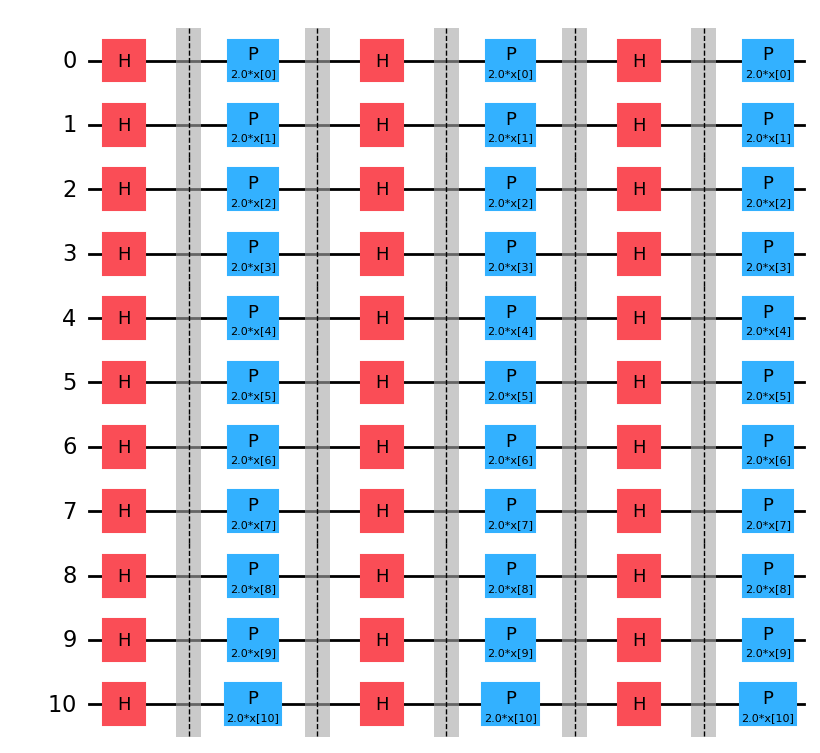

In [124]:
from qiskit.circuit.library import z_feature_map , ZZFeatureMap , PauliFeatureMap
embbeding = z_feature_map(11, reps=3, insert_barriers=True)
embbeding.draw('mpl')

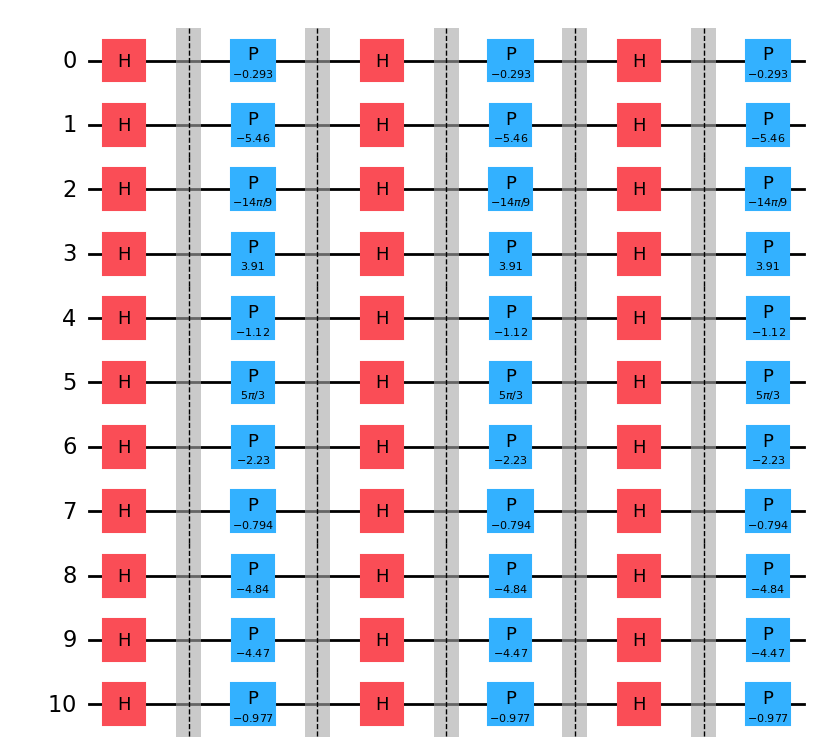

In [125]:
from qiskit import QuantumCircuit
x = 0
qc1 = embbeding.assign_parameters(samples_1['1'])
qc2 = embbeding.assign_parameters(samples_1['4'])
qc_dagger = qc2.inverse()

qc1.draw('mpl')

In [126]:

qc = QuantumCircuit(qc1.num_qubits)
qc.compose(qc1, inplace=True)
qc.compose(qc_dagger, inplace=True)
qc.measure_all()
qc.depth()

13

In [127]:
# Run this for a simulator
from qiskit.primitives import StatevectorSampler
 
from qiskit_ibm_runtime import Options, Session, Sampler
 
num_shots = 10000
 

sampler = StatevectorSampler()
results = sampler.run([qc], shots=num_shots).result()
counts_bit = results[0].data.meas.get_counts()
counts = results[0].data.meas.get_int_counts()

In [128]:
counts.get(0, 0) / num_shots

0.0233

In [129]:
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(name="Usask-Main")
# print(service.backends())

In [ ]:
# from qiskit_ibm_runtime import QiskitRuntimeService
# print(QiskitRuntimeService.saved_accounts())  

In [131]:
n_q = 11
def Q_kernel_circuit (sample,x1,x2,n_q):
    # this is kernel estimation by mesurements, one would need to execute this QC multiple times and check how many of this
    # times the measured state was the 0...0 state, so #0 states/# all shots would give the aproximate probability wich is equal
    # to the value of the inner product, 
    embbeding = embbeding = z_feature_map(n_q, reps=3, insert_barriers=True)
    qc_1 = embbeding.assign_parameters(sample[str(x1)])
    qc_2 = embbeding.assign_parameters(sample[str(x2)])
    qc_2x = qc_2.inverse()
    qc = QuantumCircuit(qc_1.num_qubits)
    qc.compose(qc_1,inplace= True)
    qc.compose(qc_2x, inplace=True)
    qc.measure_all()
    return qc

from qiskit_aer import AerSimulator


simulator = AerSimulator()

def Quantum_kernel_sim(sample,x1,x2,n_q, shots ):
    qc = Q_kernel_circuit(sample,x1,x2,n_q)
    # simulator 
    t_qc = transpile(qc, simulator)
    result = simulator.run(t_qc, shots=shots).result()
    counts = result.get_counts()

    # calculating prob.
    zero_state = '0' * n_q
    prob = counts.get(zero_state, 0) / shots
    prob = float(f"{prob:.9f}")
    return prob
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit import transpile

service = QiskitRuntimeService(name="Usask-Main")         
service.backends(simulator=False, operational=True)
backend = service.backend("ibm_quebec")


def Quantum_kernel(x1, x2, n_q, shots):
    qc = Q_kernel_circuit(x1, x2, n_q)
   
    t_qc = transpiler(qc, backend, optimization_level=1)
    
    sampler = Sampler(backend)     
    job = sampler.run([t_qc], shots=shots)
    result = job.result()
    counts = result[0].data.meas.get_counts()      
    zero_state = '0' * n_q
    prob = counts.get(zero_state, 0) / shots
    return float(f"{prob:.9f}")

# def Quantum_kernel_sim(_, x1, x2, n_q, shots):
#     """Versión que no usa diccionario externo: calcula directamente desde x1, x2."""
#     embbeding = z_feature_map(n_q, reps=3, insert_barriers=True)
#     qc_1 = embbeding.assign_parameters({embbeding.parameters[i]: x1[i] for i in range(len(x1))})
#     qc_2 = embbeding.assign_parameters({embbeding.parameters[i]: x2[i] for i in range(len(x2))})
#     qc_2x = qc_2.inverse()

#     qc = QuantumCircuit(qc_1.num_qubits)
#     qc.compose(qc_1, inplace=True)
#     qc.compose(qc_2x, inplace=True)

#     t_qc = transpile(qc, simulator)
#     result = simulator.run(t_qc, shots=shots).result()
#     counts = result.get_counts()
#     prob_zero = counts.get('0'*n_q, 0) / shots
#     return prob_zero



In [132]:
def kernel_mat_sim(A, B):
    mat = []
    for a in A:
        row = []
        for b in B:
            row.append(Quantum_kernel_sim(a, b, n_q,10000))
        mat.append(row)
    return np.array(mat)

In [133]:
def stabilize_kernel(K, eps=1e-8):
    K = (K + K.T)/2
    K = K + eps * np.eye(K.shape[0])
    
    D = np.sqrt(np.diag(K))
    K = K / np.outer(D, D)
    return K


In [134]:

from functools import lru_cache
import numpy as np
from sklearn.metrics import accuracy_score

train_idx = {str(k): i for i, k in enumerate(standar_fold_1_X_train)}
test_idx  = {str(k): i for i, k in enumerate(standar_fold_1_X_val)}


@lru_cache(maxsize=None)
def k_given_cached(a, b):
    return k_raw(a, b)

def k_given_for_svm(xi, xj):
    return float(k_given_cached(str(xi), str(xj)))




In [135]:

kernel_wrapper = lambda x1, x2: Quantum_kernel_sim(sample, x1, x2, n_q=8, shots=10000)


classifier = SVM(C=1, kernel='Given', k_given=kernel_wrapper, eps=1e-8)

In [136]:

train = {k: samples_1[k] for k in [str(i) for i in range(0,40)]}

shots = 5000
X_train = np.array(list(train.keys()))   

test = {k: samples_1_test[k] for k in [str(i) for i in range(0,40)]}

shots = 5000
X_test = np.array(list(train.keys()))



In [ ]:

# def k_raw(a, b, n_q=8, shots=10000):

#     for sd in candidate_dicts:
#         if a in sd and b in sd:
#             try:
#                 return float(Quantum_kernel_sim(sd, a, b, n_q=n_q, shots=shots))
#             except Exception as e:
#                 raise ValueError(f"Error en fallback cuántico con dict común para ({a},{b}): {e}")

    
#     vec_a = None
#     vec_b = None
#     for sd in candidate_dicts:
#         if vec_a is None and a in sd:
#             vec_a = sd[a]
#         if vec_b is None and b in sd:
#             vec_b = sd[b]
#         if vec_a is not None and vec_b is not None:
#             break

#     if vec_a is not None and vec_b is not None:
        
#         temp = {str(a): vec_a, str(b): vec_b}
#         try:
#             return float(Quantum_kernel_sim(temp, str(a), str(b), n_q=n_q, shots=shots))
#         except Exception as e:
#             raise ValueError(f"Error en fallback cuántico con dict temporal para ({a},{b}): {e}")

    
#     missing = []
#     if vec_a is None:
#         missing.append(a)
#     if vec_b is None:
#         missing.append(b)
#     raise KeyError(f"No encontré las claves {missing} en ningún samples_* dict.")


In [139]:
from functools import partial
kernel_wrapper = partial(Quantum_kernel_sim, n_q=11, shots=10000)

classifier = SVM(kernel='Given', k_given=kernel_wrapper)
classifier.fit(X_train, y_train, sample=samples_1)


     pcost       dcost       gap    pres   dres
 0:  1.1890e+02 -8.8759e+02  1e+03  5e-15  3e-15
 1:  6.5426e+00 -1.1911e+02  1e+02  1e-16  1e-15
 2: -1.9464e+01 -3.3213e+01  1e+01  9e-16  5e-16
 3: -2.0750e+01 -2.1330e+01  6e-01  4e-16  3e-16
 4: -2.0756e+01 -2.0763e+01  7e-03  1e-15  3e-16
 5: -2.0756e+01 -2.0756e+01  7e-05  9e-16  3e-16
 6: -2.0756e+01 -2.0756e+01  7e-07  4e-16  3e-16
Optimal solution found.


SVM(k_given=functools.partial(<function Quantum_kernel_sim at 0x7fd380b62480>, n_q=11, shots=10000),
    kernel='Given')

In [140]:
classifier.sample = samples_1
y_pred_val = classifier.predict(X_test) 

In [141]:
training_data_accuracy = accuracy_score( fold_1_y_train, y_pred_val)
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  1.0


In [142]:
classifier.sample = samples_1_test
y_pred_val_1 = classifier.predict(X_test)  


In [143]:
#########
training_data_accuracy_1 = accuracy_score( fold_1_y_val, y_pred_val_1)
print('Accuracy score of the test data : ',  training_data_accuracy_1)

Accuracy score of the test data :  0.6


In [144]:
classifier.fit(X_train, y_train, sample=samples_2)

     pcost       dcost       gap    pres   dres
 0:  1.2615e+02 -9.0067e+02  1e+03  3e-15  3e-15
 1:  8.2999e+00 -1.1754e+02  1e+02  2e-15  1e-15
 2: -1.8532e+01 -3.2699e+01  1e+01  4e-16  5e-16
 3: -1.9942e+01 -2.0590e+01  6e-01  9e-16  4e-16
 4: -1.9951e+01 -1.9960e+01  9e-03  2e-15  3e-16
 5: -1.9951e+01 -1.9951e+01  9e-05  2e-15  3e-16
 6: -1.9951e+01 -1.9951e+01  9e-07  9e-16  3e-16
Optimal solution found.


SVM(k_given=functools.partial(<function Quantum_kernel_sim at 0x7fd380b62480>, n_q=11, shots=10000),
    kernel='Given')

In [145]:
classifier.sample = samples_2
y_pred_val = classifier.predict(X_test) 

In [146]:
training_data_accuracy = accuracy_score( fold_2_y_train, y_pred_val)
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.525


In [147]:
classifier.sample = samples_2_test
y_pred_val_2 = classifier.predict(X_test)

In [148]:
##############
training_data_accuracy_2 = accuracy_score( fold_2_y_val, y_pred_val_2)
print('Accuracy score of the test data : ',  training_data_accuracy_2)

Accuracy score of the test data :  0.425


In [149]:
classifier.fit(X_train, y_train, sample=samples_3)

KeyboardInterrupt: 

In [ ]:
classifier.sample = samples_3
y_pred_val = classifier.predict(X_test) 

In [ ]:
training_data_accuracy = accuracy_score( fold_3_y_train, y_pred_val)
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.35


In [ ]:
classifier.sample = samples_3_test
y_pred_val_3 = classifier.predict(X_test) 

In [ ]:
###############################3
training_data_accuracy_3 = accuracy_score( fold_3_y_val, y_pred_val_3)
print('Accuracy score of the training data : ', training_data_accuracy_3)

Accuracy score of the training data :  0.225


In [ ]:
classifier.fit(X_train, y_train, sample=samples_4)

     pcost       dcost       gap    pres   dres
 0:  1.0874e+02 -1.0678e+03  1e+03  9e-15  3e-15
 1:  5.3014e+00 -1.2399e+02  1e+02  9e-16  1e-15
 2: -2.1976e+01 -3.6843e+01  1e+01  2e-15  8e-16
 3: -2.3445e+01 -2.4361e+01  9e-01  2e-15  3e-16
 4: -2.3466e+01 -2.3495e+01  3e-02  2e-15  3e-16
 5: -2.3467e+01 -2.3467e+01  4e-04  2e-15  3e-16
 6: -2.3467e+01 -2.3467e+01  4e-06  2e-16  4e-16
Optimal solution found.


SVM(k_given=functools.partial(<function Quantum_kernel_sim at 0x7f3dd80b1120>, n_q=10, shots=10000),
    kernel='Given')

In [ ]:
classifier.sample = samples_4
y_pred_val = classifier.predict(X_test) 

In [ ]:
training_data_accuracy = accuracy_score( fold_4_y_train, y_pred_val)
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.35


In [ ]:
classifier.sample = samples_4_test
y_pred_val_4 = classifier.predict(X_test) 

In [ ]:
########
training_data_accuracy_4 = accuracy_score( fold_4_y_val, y_pred_val_4)
print('Accuracy score of the training data : ',  training_data_accuracy_4)

Accuracy score of the training data :  0.5


In [ ]:
CV = training_data_accuracy_4 + (training_data_accuracy_3) + training_data_accuracy_2 + training_data_accuracy_1
print("Acording to the cross validation the expected Eout without kernel is == " ,  CV/4 )
print("So the Accuracy score is == " ,  CV/4)
val = (CV/4)*100
valpercent = format(val, ".4g")
print("So we get a" , valpercent, "% Accuracy")

Acording to the cross validation the expected Eout without kernel is ==  0.43125
So the Accuracy score is ==  0.43125
So we get a 43.12 % Accuracy


In [ ]:
print(1- training_data_accuracy_3)

0.775
